# F1 25 (2026 Season Pack) Driver Ratings vs. Real-World Performance

This notebook checks how well EA's in-game F1 driver ratings (F1 25: 2026
Season Pack, launched June 2026 -- see the project README for why this is
not a "F1 26" game) line up with actual 2025/2026 Formula 1 results.

**Sample size disclaimer up front:** there are only ~20-22 drivers on the
grid. Every result below is descriptive -- correlations, a scatter plot, and
a ranked over/under-rated table. None of it has the statistical power to
support hypothesis tests, regression modeling, or anything beyond "here's
what the data looks like." Treat this as an exploratory sanity check, not a
rigorous study.


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

df = pd.read_csv("../data/processed/f1_ratings_vs_results.csv")
df.shape


(22, 18)

In [2]:
df.sort_values("overall", ascending=False).reset_index(drop=True)


,launch_rank,driver,team,overall,experience,racecraft,awareness,pace,position_2025,points_2025,wins_2025,round_reached_2025,constructor_2025,position_2026,points_2026,wins_2026,round_reached_2026,constructor_2026
0,1,Max Verstappen,Red Bull Racing,95,87,96,85,96,2.0,421.0,8.0,24.0,Red Bull,7,76.0,0,9,Red Bull
1,2,Lando Norris,McLaren,94,81,89,80,94,1.0,423.0,7.0,24.0,McLaren,5,97.0,0,9,McLaren
2,3,George Russell,Mercedes,93,83,94,93,94,4.0,319.0,2.0,24.0,Mercedes,2,154.0,2,9,Mercedes
3,4,Charles Leclerc,Ferrari,92,83,92,91,93,5.0,242.0,0.0,24.0,Ferrari,4,108.0,1,9,Ferrari
4,5,Lewis Hamilton,Ferrari,91,98,93,91,89,6.0,156.0,0.0,24.0,Ferrari,3,147.0,1,9,Ferrari
5,6,Oscar Piastri,McLaren,91,77,95,81,92,3.0,410.0,7.0,24.0,McLaren,6,82.0,0,9,McLaren
6,7,Fernando Alonso,Aston Martin,90,99,90,81,87,10.0,56.0,0.0,24.0,Aston Martin,18,1.0,0,9,Aston Martin
7,8,Carlos Sainz,Williams,86,88,88,80,86,9.0,64.0,0.0,24.0,Williams,15,6.0,0,9,Williams
8,9,Alexander Albon,Williams,85,84,87,77,85,8.0,73.0,0.0,24.0,Williams,16,5.0,0,9,Williams
9,10,Sergio Perez,Cadillac,85,92,83,81,85,NaN,NaN,NaN,NaN,NaN,21,0.0,0,9,Cadillac F1 Team


## 1. Ratings vs. 2025 season results (complete season)

2025 was a full, completed season, so points/position here are the more
statistically stable ground truth. Three drivers in the ratings table have
no 2025 result (Sergio Perez and Valtteri Bottas were out of full-time
seats in 2025; Arvid Lindblad wasn't on the 2025 grid), so they're dropped
for this comparison only.


In [3]:
d25 = df.dropna(subset=["points_2025"]).copy()
d25["position_2025"] = d25["position_2025"].astype(int)
print(f"drivers with a 2025 result: {len(d25)} / {len(df)}")

attrs = ["overall", "experience", "racecraft", "awareness", "pace"]
targets = {"points_2025": "2025 points", "position_2025": "2025 championship position"}

rows = []
for attr in attrs:
    for tgt, tgt_label in targets.items():
        r, p = stats.pearsonr(d25[attr], d25[tgt])
        rho, p_s = stats.spearmanr(d25[attr], d25[tgt])
        rows.append({
            "attribute": attr, "vs": tgt_label,
            "pearson_r": round(r, 3), "pearson_p": round(p, 4),
            "spearman_rho": round(rho, 3), "spearman_p": round(p_s, 4),
        })
corr_2025 = pd.DataFrame(rows)
corr_2025


drivers with a 2025 result: 19 / 22


,attribute,vs,pearson_r,pearson_p,spearman_rho,spearman_p
0,overall,2025 points,0.804,0.0000,0.880,0.0000
1,overall,2025 championship position,-0.882,0.0000,-0.878,0.0000
2,experience,2025 points,0.143,0.5589,0.320,0.1822
3,experience,2025 championship position,-0.365,0.1242,-0.326,0.1726
4,racecraft,2025 points,0.725,0.0004,0.842,0.0000
5,racecraft,2025 championship position,-0.833,0.0000,-0.840,0.0000
6,awareness,2025 points,0.476,0.0394,0.562,0.0123
7,awareness,2025 championship position,-0.551,0.0145,-0.553,0.0141
8,pace,2025 points,0.865,0.0000,0.914,0.0000
9,pace,2025 championship position,-0.896,0.0000,-0.911,0.0000


Note position is *inverted* relative to points (1st place is the best
position but the lowest number), so we'd expect `overall` to correlate
**positively** with points and **negatively** with position if the game's
ratings track real results.


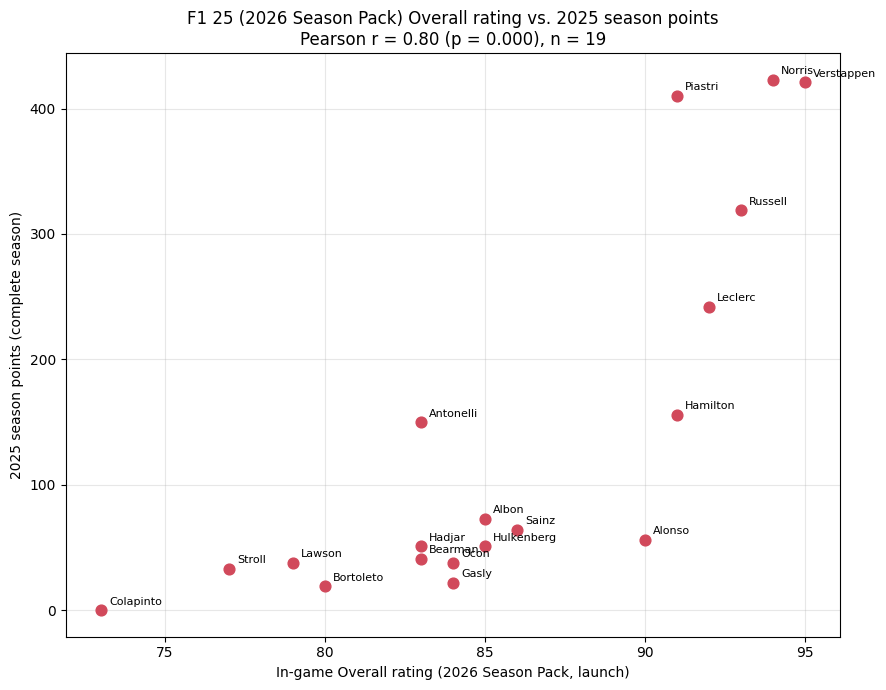

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(d25["overall"], d25["points_2025"], s=60, color="#d1495b", zorder=3)

for _, row in d25.iterrows():
    ax.annotate(
        row["driver"].split(" ")[-1],
        (row["overall"], row["points_2025"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

r, p = stats.pearsonr(d25["overall"], d25["points_2025"])
ax.set_title(f"F1 25 (2026 Season Pack) Overall rating vs. 2025 season points\n"
             f"Pearson r = {r:.2f} (p = {p:.3f}), n = {len(d25)}")
ax.set_xlabel("In-game Overall rating (2026 Season Pack, launch)")
ax.set_ylabel("2025 season points (complete season)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("overall_vs_2025_points.png", dpi=130)
plt.show()


## 2. Ratings vs. 2026 season results (in progress)

The 2026 Season Pack ratings are meant to reflect the driver as of the 2026
season, so this is arguably the more relevant comparison -- but 2026 is only
partway through (whatever round Jolpica-F1 had recorded when
`fetch_f1_results.py` last ran), so points totals are smaller and noisier
than a full season, and one early result (e.g. a single win or a crash) can
swing a driver's total by a large relative amount.


In [5]:
d26 = df.dropna(subset=["points_2026"]).copy()
d26["position_2026"] = d26["position_2026"].astype(int)
round_reached = int(d26["round_reached_2026"].iloc[0])
print(f"drivers with a 2026 result: {len(d26)} / {len(df)}, through round {round_reached}")

rows = []
targets_26 = {"points_2026": "2026 points (partial season)", "position_2026": "2026 standing position"}
for attr in attrs:
    for tgt, tgt_label in targets_26.items():
        r, p = stats.pearsonr(d26[attr], d26[tgt])
        rho, p_s = stats.spearmanr(d26[attr], d26[tgt])
        rows.append({
            "attribute": attr, "vs": tgt_label,
            "pearson_r": round(r, 3), "pearson_p": round(p, 4),
            "spearman_rho": round(rho, 3), "spearman_p": round(p_s, 4),
        })
corr_2026 = pd.DataFrame(rows)
corr_2026


drivers with a 2026 result: 22 / 22, through round 9


,attribute,vs,pearson_r,pearson_p,spearman_rho,spearman_p
0,overall,2026 points (partial season),0.481,0.0235,0.347,0.1137
1,overall,2026 standing position,-0.391,0.0717,-0.358,0.1017
2,experience,2026 points (partial season),0.023,0.9194,-0.377,0.0839
3,experience,2026 standing position,0.196,0.3827,0.377,0.0833
4,racecraft,2026 points (partial season),0.481,0.0234,0.447,0.0371
5,racecraft,2026 standing position,-0.443,0.0389,-0.457,0.0324
6,awareness,2026 points (partial season),0.321,0.1459,0.110,0.6246
7,awareness,2026 standing position,-0.142,0.5292,-0.135,0.5501
8,pace,2026 points (partial season),0.541,0.0093,0.444,0.0382
9,pace,2026 standing position,-0.474,0.0258,-0.456,0.0331


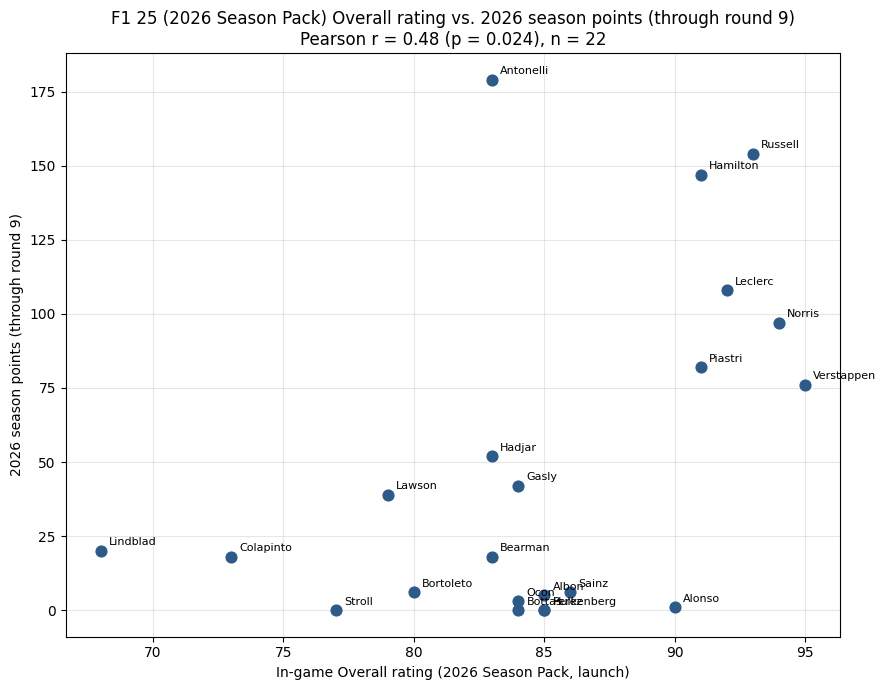

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(d26["overall"], d26["points_2026"], s=60, color="#2e5a88", zorder=3)

for _, row in d26.iterrows():
    ax.annotate(
        row["driver"].split(" ")[-1],
        (row["overall"], row["points_2026"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

r, p = stats.pearsonr(d26["overall"], d26["points_2026"])
ax.set_title(f"F1 25 (2026 Season Pack) Overall rating vs. 2026 season points (through round {round_reached})\n"
             f"Pearson r = {r:.2f} (p = {p:.3f}), n = {len(d26)}")
ax.set_xlabel("In-game Overall rating (2026 Season Pack, launch)")
ax.set_ylabel(f"2026 season points (through round {round_reached})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("overall_vs_2026_points.png", dpi=130)
plt.show()


## 3. Who does the game over/under-rate?

For each season we rank drivers two ways -- by in-game Overall rating, and
by real-world finishing position -- and look at the delta. A large positive
delta means the game rates the driver's *rank* much better than their
real-world result (over-rated by the game); a large negative delta means
the reverse (under-rated).

Rank deltas are used rather than raw points/rating deltas since ratings
(0-100 scale) and points (0-400+ scale, season-dependent) aren't
directly comparable -- but their *rankings* are.


In [7]:
def rank_deltas(d, points_col, label):
    out = d[["driver", "team", "overall", points_col]].copy()
    out["game_rank"] = out["overall"].rank(ascending=False, method="min").astype(int)
    out["real_rank"] = out[points_col].rank(ascending=False, method="min").astype(int)
    out["delta (game_rank - real_rank)"] = out["game_rank"] - out["real_rank"]
    out = out.sort_values("delta (game_rank - real_rank)")
    out.attrs["label"] = label
    return out

deltas_2025 = rank_deltas(d25, "points_2025", "2025")
deltas_2026 = rank_deltas(d26, "points_2026", "2026")


### Most *under-rated* by the game (game rank worse than real result), 2025 season
Negative delta: the game ranks them lower than their real-world points rank.


In [8]:
deltas_2025.head(6)


,driver,team,overall,points_2025,game_rank,real_rank,delta (game_rank - real_rank)
11,Pierre Gasly,Alpine,84,22.0,11,17,-6
6,Fernando Alonso,Aston Martin,90,56.0,7,10,-3
13,Esteban Ocon,Haas,84,38.0,11,14,-3
10,Nico Hulkenberg,Audi,85,51.0,9,11,-2
17,Gabriel Bortoleto,Audi,80,19.0,16,18,-2
0,Max Verstappen,Red Bull Racing,95,421.0,1,2,-1


### Most *over-rated* by the game (game rank better than real result), 2025 season
Positive delta: the game ranks them higher than their real-world points rank.


In [9]:
deltas_2025.tail(6).sort_values("delta (game_rank - real_rank)", ascending=False)


,driver,team,overall,points_2025,game_rank,real_rank,delta (game_rank - real_rank)
14,Kimi Antonelli,Mercedes,83,150.0,13,7,6
18,Liam Lawson,Racing Bulls,79,38.0,17,14,3
19,Lance Stroll,Aston Martin,77,33.0,18,16,2
15,Isack Hadjar,Racing Bulls,83,51.0,13,11,2
5,Oscar Piastri,McLaren,91,410.0,5,3,2
1,Lando Norris,McLaren,94,423.0,2,1,1


### Same view for the (partial) 2026 season


In [10]:
print("Most under-rated by the game (2026 so far):")
display(deltas_2026.head(6))

print("Most over-rated by the game (2026 so far):")
display(deltas_2026.tail(6).sort_values("delta (game_rank - real_rank)", ascending=False))


Most under-rated by the game (2026 so far):


,driver,team,overall,points_2026,game_rank,real_rank,delta (game_rank - real_rank)
6,Fernando Alonso,Aston Martin,90,1.0,7,18,-11
9,Sergio Perez,Cadillac,85,0.0,9,19,-10
10,Nico Hulkenberg,Audi,85,0.0,9,19,-10
8,Alexander Albon,Williams,85,5.0,9,16,-7
12,Valtteri Bottas,Cadillac,84,0.0,12,19,-7
0,Max Verstappen,Red Bull Racing,95,76.0,1,7,-6


Most over-rated by the game (2026 so far):


,driver,team,overall,points_2026,game_rank,real_rank,delta (game_rank - real_rank)
14,Kimi Antonelli,Mercedes,83,179.0,15,1,14
21,Arvid Lindblad,Racing Bulls,68,20.0,22,11,11
18,Liam Lawson,Racing Bulls,79,39.0,19,10,9
20,Franco Colapinto,Alpine,73,18.0,21,12,9
15,Isack Hadjar,Racing Bulls,83,52.0,15,8,7
17,Gabriel Bortoleto,Audi,80,6.0,18,14,4


## 4. Which sub-attribute tracks real results best?

Overall is a blend of Experience, Racecraft, Awareness, and Pace. Do any of
those track real-world results *better* than the blended Overall number?


In [11]:
summary = corr_2025.pivot(index="attribute", columns="vs", values="pearson_r")
summary = summary.reindex(attrs + [a for a in summary.index if a not in attrs])
summary


vs,2025 championship position,2025 points
attribute,,
overall,-0.882,0.804
experience,-0.365,0.143
racecraft,-0.833,0.725
awareness,-0.551,0.476
pace,-0.896,0.865


## 5. Takeaways

- With only ~20-22 drivers this is a *descriptive* look, not a statistically
  powered study -- p-values are reported above for completeness but
  shouldn't be over-interpreted at this n.
- Directionally, in-game Overall rating shows a positive relationship with
  real-world points and a negative relationship with real-world finishing
  position in both the 2025 (complete season) and 2026 (partial season)
  comparisons above -- consistent with the ratings being a reasonable, if
  imprecise, proxy for real driver performance.
- The rank-delta table surfaces the specific drivers where the game's
  Overall rating diverges most from real-world results -- useful as a
  sanity check on which individual ratings might be stale or overly
  reliant on reputation/experience versus current-season form (2026's
  in-season EA update, e.g. bumping Antonelli after his early-season form
  and trimming Norris after his, suggests EA is already trying to correct
  exactly this kind of drift -- see the README for details).
- No value-prediction / moneyball section here, unlike the fifa-analysis
  playbook -- F1 has no per-driver market-value concept for that analog to
  target.
